In [1]:
# Uso do notebook para testar hipoteses antes de ir para o power bi
# Importando Pandas para obter base gold (tratada)
import pandas as pd

# Importando a base gold
df = pd.read_csv('../data/processed/base_historico.csv')

In [2]:
df.head()

,RA,Fase,Turma,Nome Anonimizado,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra,...,Ing,IPV,IAN,Fase Ideal,Defasagem,Ano,Data de Nasc,IPP,Escola,Ativo/ Inativo
0,RA-1,7,A,Aluno-1,2003.0,19,Menina,2016,Escola Pública,Quartzo,...,6.0,7.278,5.0,Fase 8 (Universitários),-1,2022,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005.0,17,Menina,2017,Rede Decisão,Ametista,...,9.7,6.778,10.0,Fase 7 (3º EM),0,2022,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005.0,17,Menina,2016,Rede Decisão,Ágata,...,6.9,7.556,10.0,Fase 7 (3º EM),0,2022,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005.0,17,Menino,2017,Rede Decisão,Quartzo,...,8.7,5.278,10.0,Fase 7 (3º EM),0,2022,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005.0,17,Menina,2016,Rede Decisão,Ametista,...,5.7,7.389,10.0,Fase 7 (3º EM),0,2022,NaN,NaN,NaN,NaN


In [3]:
# Agrupando por ano para obter a média da nota IDA ao longo dos anos
df_media_ida_ano = df.groupby('Ano')['IDA'].mean().reset_index()
df_media_ida_ano.head()

,Ano,IDA
0,2022,6.092907
1,2023,6.663394
2,2024,6.351422


In [4]:
# Agrupando por Fase para obter a média da nota IDA ao longo dos anos
df_media_ida_fase = df.groupby('Fase')['IDA'].mean().reset_index()
df_media_ida_fase.head(20)

,Fase,IDA
0,0,7.302836
1,1,6.684091
2,2,6.187106
3,3,5.392974
4,4,5.966608
5,5,6.140148
6,6,6.920395
7,7,5.932108
8,8,8.000000
9,9,NaN


In [5]:
# Agrupando por ano e por fase para obter a média da nota IDA ao longo dos anos e fases
df_media_ida_ano_fase = df.groupby(['Ano', 'Fase'])['IDA'].mean().reset_index()
df_media_ida_ano_fase.head(30)

,Ano,Fase,IDA
0,2022,0,7.140000
1,2022,1,6.464062
2,2022,2,5.406452
3,2022,3,5.141892
4,2022,4,6.052632
5,2022,5,5.873333
6,2022,6,6.694444
7,2022,7,5.252381
8,2023,0,7.422078
9,2023,1,6.814451


A correlação matemática entre IEG e IDA é: 0.54


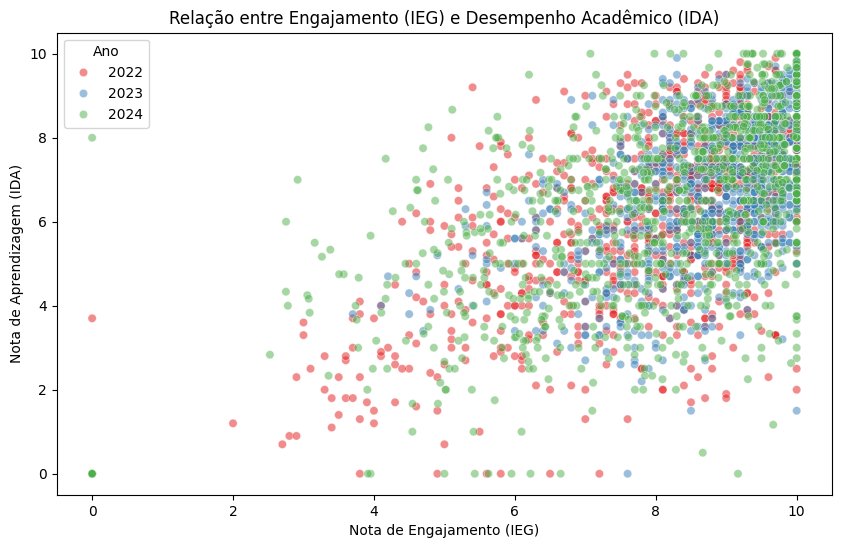

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlação entre as variaveis IEG e IDA
correlacao = df['IEG'].corr(df['IDA'])
print(f"A correlação matemática entre IEG e IDA é: {correlacao:.2f}")

# Criando um gráfico de dispersão para visualizar a relação entre IEG e IDA
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='IEG', y='IDA', hue='Ano', palette='Set1', alpha=0.5)

plt.title('Relação entre Engajamento (IEG) e Desempenho Acadêmico (IDA)')
plt.xlabel('Nota de Engajamento (IEG)')
plt.ylabel('Nota de Aprendizagem (IDA)')

plt.show()

A correlação matemática entre IAA e IDA é: 0.12


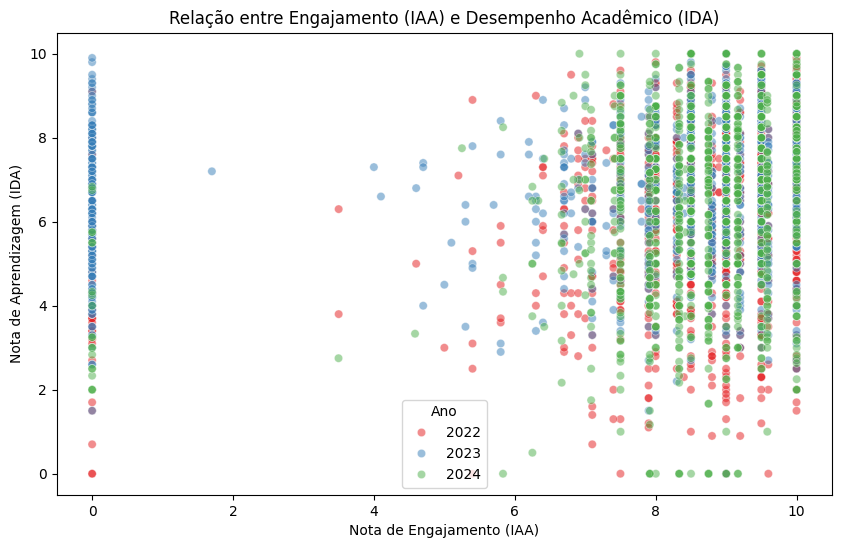

In [7]:
# Correlação entre as variaveis IAA e IDA
correlacao2 = df['IAA'].corr(df['IDA'])
print(f"A correlação matemática entre IAA e IDA é: {correlacao2:.2f}")

# Criando um gráfico de dispersão para visualizar a relação entre IAA e IDA
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='IAA', y='IDA', hue='Ano', palette='Set1', alpha=0.5)

plt.title('Relação entre Engajamento (IAA) e Desempenho Acadêmico (IDA)')
plt.xlabel('Nota de Engajamento (IAA)')
plt.ylabel('Nota de Aprendizagem (IDA)')

plt.show()

In [8]:
# Coluna calculando a difereçe entre como o aluno se vê e a nota real
df['Gap_Realidade'] = df['IAA'] - df['IDA']

# Média do gap
print(df['Gap_Realidade'].describe())

count    2851.000000
mean        1.552776
std         3.080380
min        -9.900000
25%         0.400000
50%         1.800000
75%         3.400000
max         9.600000
Name: Gap_Realidade, dtype: float64


In [10]:
# Verificando a correlação das variaveis com o IPV
# Selecionando apenas colunas de correlação
colunas_indicadores = ['INDE', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN']

# Calculando a matriz de correlação
matriz_correlacao = df[colunas_indicadores].corr()

# Isolando o alvo IPV e ordenando pela correlação
ranking_ipv = matriz_correlacao['IPV'].sort_values(ascending=False)

print("--- O que mais influencia o ponto de virada (IPV)? ---")
print(ranking_ipv)

--- O que mais influencia o ponto de virada (IPV)? ---
IPV     1.000000
INDE    0.720896
IPP     0.606649
IEG     0.558200
IDA     0.557072
IAN     0.148880
IAA     0.062728
IPS    -0.048750
Name: IPV, dtype: float64


In [18]:
# Agupando pela coluna de defasagem e calculando a media do IPS e IDA
analise_defasagem = df.groupby('Defasagem')[['IPS', 'IDA']].mean().round(2)

print("--- Médias de IPS e IDA por anos de defasagem ---")
print(analise_defasagem)

--- Médias de IPS e IDA por anos de defasagem ---
            IPS   IDA
Defasagem            
-5         7.50  0.00
-4         5.26  3.00
-3         5.71  4.98
-2         6.20  5.89
-1         6.34  6.35
 0         6.31  6.60
 1         6.13  7.02
 2         5.96  6.07
 3         9.07  4.75


In [19]:
# Corrlação entre profissionais e a nota do aluno
corr_profissionais = df[['IPS', 'IPP', 'IDA']].corr().round(2)

print("\n--- Correlação: Psicossocial vs Psicopedagógico vs Aprendizagem ---")
print(corr_profissionais)


--- Correlação: Psicossocial vs Psicopedagógico vs Aprendizagem ---
      IPS   IPP   IDA
IPS  1.00  0.06  0.02
IPP  0.06  1.00  0.37
IDA  0.02  0.37  1.00
